In [1]:
!nvidia-smi

Fri Apr 17 01:17:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060        Off |   00000000:01:00.0 Off |                  N/A |
|  0%   49C    P8             14W /  170W |     132MiB /  12288MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
from torch import nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split
from datasets import load_dataset
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

/home/uno21/.virtualenvs/traffic-sign-cnn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Usando: cuda


In [3]:
from torch.utils.data import Dataset

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3337, 0.3064, 0.3171],
                         std=[0.2672, 0.2564, 0.2629])
])

transform_train = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3337, 0.3064, 0.3171],
                         std=[0.2672, 0.2564, 0.2629])
])

class GTSRBDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.data = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]['image'].convert('RGB')
        label = self.data[idx]['label']
        if self.transform:
            image = self.transform(image)
        return image, label

ds = load_dataset("tanganke/gtsrb")
test_dataset = GTSRBDataset(ds['test'], transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
print(f"Test: {len(test_dataset)} imágenes")

Test: 12630 imágenes


In [4]:
class CNNBaseline(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units*2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv_block_3 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units*2, out_channels=hidden_units*4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(in_features=hidden_units*4 * 4 * 4, out_features=256),
            nn.ReLU(),
            nn.Linear(256, output_shape)
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.conv_block_3(x)
        x = self.classifier(x)
        return x

model = CNNBaseline(input_shape=3, hidden_units=32, output_shape=43).to(device)
model.load_state_dict(torch.load("/home/uno21/models/baseline_cnn.pth", map_location=device))
model.eval()
print("Modelo cargado.")

Modelo cargado.


In [5]:
from torchvision import models

# Cargar ResNet18 preentrenado en ImageNet
model_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Ver la arquitectura
print(model_resnet)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [6]:
model_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model_resnet.fc = nn.Linear(512, 43)

for param in model_resnet.parameters():
    param.requires_grad = False
for param in model_resnet.layer4.parameters():
    param.requires_grad = True
for param in model_resnet.fc.parameters():
    param.requires_grad = True

model_resnet = model_resnet.to(device)

trainable = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
print(f"Entrenables: {trainable:,}")

Entrenables: 8,415,787


In [7]:
# Splits
full_train = GTSRBDataset(ds['train'], transform=transform_train)
test_dataset = GTSRBDataset(ds['test'], transform=transform)

train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size
train_dataset, val_dataset = random_split(full_train, [train_size, val_size])

print(f"Train: {len(train_dataset)}")
print(f"Val: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")

Train: 21312
Val: 5328
Test: 12630


In [8]:
full_train = GTSRBDataset(ds['train'], transform=transform_train)

train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size
train_dataset, val_dataset = random_split(full_train, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

In [9]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_resnet.parameters()),
    lr=0.0001
)

In [10]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    """ Performs a training with model tryinh to learn on dta_loader."""
    train_loss, train_acc = 0,0

    # put model into training mode
    model.train()

    # add a loop to loop through the training batches
    for batch, (X, y) in enumerate(data_loader): # X, y can also be named "images, labels"
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. forward pass (outputs the raw logits from the model)
        y_pred = model(X)

        # 2. Calculate loss and accuracy (per batch)
        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulate train loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1)) # go from logits -> prediction labels

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()
    # Divide total train loss by lenght of train dataloader
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)

    print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc:.2f}%")

In [11]:
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device =device):
    """ Performs a testing loop step on model over data_loader"""
    test_loss, test_acc = 0,0

    #put model on eval mode
    model.eval()

    # Turn on inference  mode context manager
    with torch.inference_mode():
        for X, y in data_loader:
            # Send the data to target device
            X, y = X.to(device), y.to(device)

            # Forward pass
            test_pred = model(X)

            #Calculate the loss /acc
            test_loss += loss_fn(test_pred,y)
            test_acc += accuracy_fn(y_true=y,
                                    y_pred=test_pred.argmax(dim=1)) # go from logits -> prediction labels

        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)

        print(f"Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}")

In [12]:


loss_fn = nn.CrossEntropyLoss()

torch.manual_seed(42)
from timeit import default_timer as timer
from tqdm.auto import tqdm

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_pred)) * 100

def print_train_time(start, end, device=None):
    total_time = end - start
    print(f"Tiempo de entrenamiento: {total_time:.3f} segundos en {device}")
    return total_time

train_time_start = timer()
epochs = 10

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch+1}\n-----------")
    train_step(model=model_resnet,
               data_loader=train_loader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn,
               device=device)
    test_step(model=model_resnet,
              data_loader=val_loader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device=device)

train_time_end = timer()
total_train_time = print_train_time(train_time_start, train_time_end, device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1
-----------
Train loss: 1.32145 | Train acc: 63.36%


 10%|█         | 1/10 [00:05<00:49,  5.48s/it]

Test loss: 0.52245 | Test acc: 84.62
Epoch: 2
-----------
Train loss: 0.37793 | Train acc: 89.17%


 20%|██        | 2/10 [00:10<00:43,  5.43s/it]

...

Test loss: 0.06990 | Test acc: 97.75
Epoch: 9
-----------
Train loss: 0.04929 | Train acc: 98.55%


 90%|█████████ | 9/10 [00:48<00:05,  5.41s/it]

Test loss: 0.05321 | Test acc: 98.36
Epoch: 10
-----------
Train loss: 0.04126 | Train acc: 98.73%


100%|██████████| 10/10 [00:53<00:00,  5.39s/it]

Test loss: 0.06396 | Test acc: 97.92
Tiempo de entrenamiento: 53.942 segundos en cuda


In [13]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

torch.save(model_resnet.state_dict(), MODEL_PATH / "resnet18_finetuned.pth")
print("Modelo guardado.")

Modelo guardado.


In [19]:
all_preds = []
all_labels = []

model_resnet.eval()
with torch.inference_mode():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model_resnet(images).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.26      0.32      0.29        60
           1       0.60      0.54      0.57       720
           2       0.54      0.62      0.58       750
           3       0.53      0.70      0.60       450
           4       0.73      0.74      0.74       660
           5       0.61      0.47      0.53       630
           6       0.95      0.99      0.97       150
           7       0.81      0.78      0.80       450
           8       0.67      0.71      0.69       450
           9       0.90      0.90      0.90       480
          10       0.92      0.98      0.95       660
          11       0.75      0.73      0.74       420
          12       1.00      0.97      0.98       690
          13       1.00      0.99      1.00       720
          14       0.93      0.90      0.92       270
          15       1.00      1.00      1.00       210
          16       0.99      0.87      0.93       150
          17       0.94    

In [16]:
trainable = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
print(f"Entrenables: {trainable:,}")

Entrenables: 8,415,787


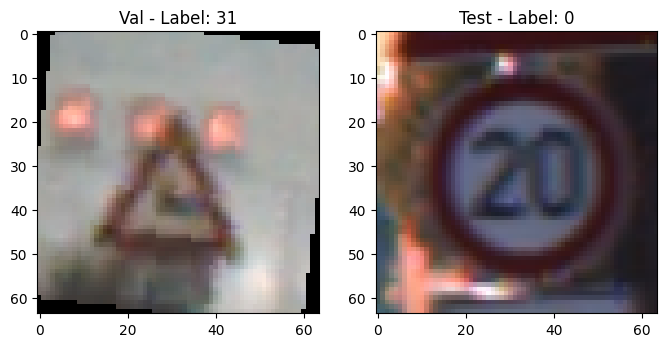

In [22]:
import torchvision.transforms.functional as F

# Imagen del val
val_img, val_lbl = val_dataset[0]
# Imagen del test
test_img, test_lbl = test_dataset[0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Desnormalizar
mean = torch.tensor([0.3337, 0.3064, 0.3171])
std = torch.tensor([0.2672, 0.2564, 0.2629])

val_show = (val_img.permute(1,2,0) * std + mean).clamp(0,1)
test_show = (test_img.permute(1,2,0) * std + mean).clamp(0,1)

axes[0].imshow(val_show)
axes[0].set_title(f"Val - Label: {val_lbl}")
axes[1].imshow(test_show)
axes[1].set_title(f"Test - Label: {test_lbl}")
plt.show()